# Minitab-Style Capability Reports

Interactive companion to `src/sixpack_report.py`.

Everything the CLI can produce, rendered **inline** — no PNG round-trip,
no reopening files:

| Report | What it answers |
|---|---|
| **Capability Sixpack** | Is the process in control *and* capable? |
| **Capability Analysis (Normal)** | Cp / Cpk / Pp / Ppk plus PPM defect rates |
| **Gage R&R (ANOVA)** | Can the measurement system be trusted? |
| **MSA Assistant** | Plain-language pass/fail against AIAG guidelines |

The module is imported, not re-implemented, so these notebooks and the
`python src/sixpack_report.py` CLI always produce identical output.

## 1. Setup

In [10]:
# Make the report module importable from the notebook.
import sys
from pathlib import Path

REPO = Path.cwd()
if not (REPO / "src" / "sixpack_report.py").exists():
    # Fall back to walking up when the notebook runs from notebooks/
    REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "src" / "sixpack_report.py").exists())

sys.path.insert(0, str(REPO / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

import sixpack_report as sr

print("sixpack_report loaded from:", sr.__file__)
print("Public API:", ", ".join(
    n for n in dir(sr) if n.startswith("generate_")
))

sixpack_report loaded from: c:\Users\dmnandlu\DeskBox\文件夹\Black belt\capability-sixpack\src\sixpack_report.py
Public API: generate_capability_analysis, generate_gage_rr_report, generate_sixpack


### Inline display hook

`generate_*` calls `fig.savefig(...)` then `plt.close(fig)`. We wrap
`savefig` so the figure is displayed **at save time**, while it is still
open, and the PNG is still written to disk exactly as before.

In [11]:
import matplotlib

_real_savefig = matplotlib.figure.Figure.savefig


def _savefig_and_display(self, *args, **kwargs):
    """Write the PNG (original behaviour), then render it inline."""
    result = _real_savefig(self, *args, **kwargs)
    display(self)
    return result


matplotlib.figure.Figure.savefig = _savefig_and_display
print("Inline display hook installed.")

Inline display hook installed.


## 2. Data and specifications

In [12]:
# Minitab's "Demo data" style process measurement, centred at 104.6.
values = sr._synthetic_data(seed=42)
print(values)
specs = sr.CapabilitySpecs(lsl=103.0, usl=110.0, target=104.0)

summary = pd.DataFrame({
    "Statistic": ["Observations", "Mean", "Std Dev (overall)",
                  "Min", "Max", "LSL", "USL", "Target"],
    "Value": [
        len(values), f"{values.mean():.3f}", f"{values.std(ddof=1):.3f}",
        f"{values.min():.3f}", f"{values.max():.3f}",
        f"{specs.lsl:.3f}", f"{specs.usl:.3f}", f"{specs.target:.3f}",
    ],
})
summary

[104.63518879 103.16207809 105.13761753 105.35280301 102.17810372
 102.89790557 104.47698808 103.99455739 104.33000358 103.41619713
 105.32794383 105.2222378  104.44536104 105.61875321 104.89910876
 103.44568738 104.80259556 103.34825944 105.37538624 104.36023301
 104.21786352 103.67825023 105.77812881 104.26941151 103.97429394
 104.06416825 105.04311586 104.86562483 104.92370284 104.94966068
 106.83763054 104.04082227 103.93047239 103.60485    105.18363797
 105.75399073 104.39283961 103.6000703  103.62337369 105.2520157
 105.36000383 105.14595454 103.82248478 104.81598352 104.69502106
 104.81328473 105.53735953 104.83080359 105.33771401 104.67130667
 104.92106164 105.30350796 103.01228011 104.26957378 104.10986281
 103.9305677  104.33673746 106.28988999 103.69910092 105.72268195
 102.81247961 104.30132344 104.85478595 105.32666275 105.47022803
 105.56662135 104.31640242 104.19747363 105.65589468 104.50774706
 103.32098747 103.48368709 103.72496612 105.28930106 104.90515316
 105.514079

,Statistic,Value
0,Observations,100
1,Mean,104.545
2,Std Dev (overall),0.845
3,Min,102.178
4,Max,106.838
5,LSL,103.000
6,USL,110.000
7,Target,104.000


## 3. Capability Sixpack

The sixpack combines six views into one report:

1. **I-Chart** — are individual measurements in statistical control?
2. **Histogram** — how is the data distributed against the spec limits?
3. **MR-Chart** — is the *short-term* (within) variation stable?
4. **Normal Probability Plot** — is the normality assumption justified?
5. **Last 25 Observations** — what is the process doing right now?
6. **Capability Plot** — how does spread compare to the spec window?

> A capable-but-unstable process and a stable-but-incapable process are
> different problems. The sixpack shows both at once.

c:\Users\dmnandlu\DeskBox\文件夹\Black belt\capability-sixpack\src\sixpack_report.py:1890: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


RecursionError: maximum recursion depth exceeded in comparison

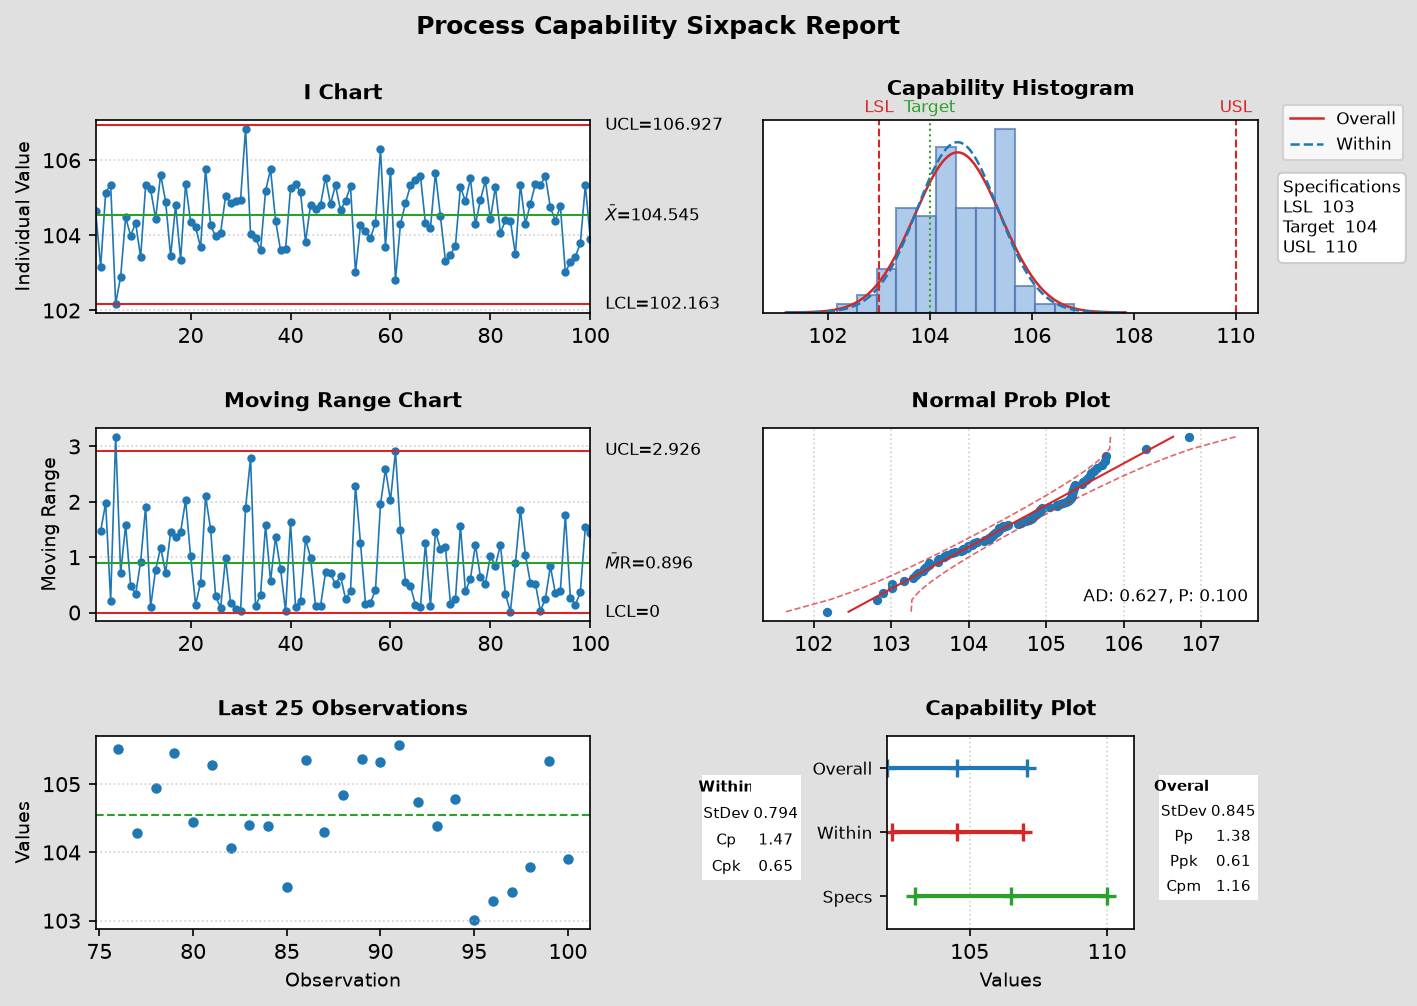

In [13]:
sixpack_path = REPO / "output" / "sixpack_report.png"

stats = sr.generate_sixpack(
    values,
    specs,
    "Process Capability Sixpack Report",
    sixpack_path,
)
print(f"Saved to {sixpack_path}")

In [ ]:
capability_table = pd.DataFrame({
    "Index": ["Cp", "Cpk", "Pp", "Ppk", "Cpm"],
    "Value": [stats.cp, stats.cpk, stats.pp, stats.ppk, stats.cpm],
})
capability_table.index = capability_table["Index"]
capability_table.round(3)

,Index,Value
Index,,
Cp,Cp,1.469
Cpk,Cpk,0.648
Pp,Pp,1.381
Ppk,Ppk,0.610
Cpm,Cpm,1.161


**How to read it:** the gap between `Cpk` and `Cp` tells you how far the
mean sits from the centre of the spec window. A large gap means the process
is *centred* poorly even if its spread is acceptable — recentre before
investing in variation reduction.

## 4. Capability Analysis (Normal)

The focused view: the capability histogram plus overall / within indices and
observed-versus-expected defect rates in parts per million.

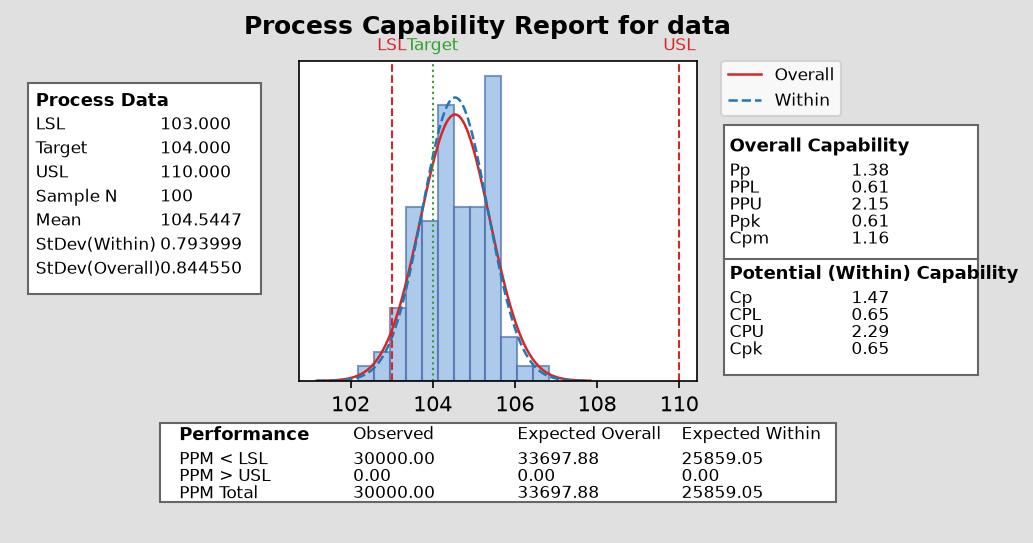

Saved to C:\Users\dmnandlu\DeskBox\文件夹\Black belt\capability-sixpack\output\capability_analysis_report.png


In [ ]:
analysis_path = REPO / "output" / "capability_analysis_report.png"

result = sr.generate_capability_analysis(
    values,
    specs,
    "Process Capability Report for data",
    analysis_path,
)
print(f"Saved to {analysis_path}")

In [ ]:
performance = result.performance

ppm_table = pd.DataFrame({
    "Defect region": ["Below LSL", "Above USL", "Total"],
    "Observed": [f"{v:,.0f}" for v in performance.observed],
    "Expected Overall": [f"{v:,.0f}" for v in performance.expected_overall],
    "Expected Within": [f"{v:,.0f}" for v in performance.expected_within],
})
ppm_table

,Defect region,Observed,Expected Overall,Expected Within
0,Below LSL,"30,000","33,698","25,859"
1,Above USL,0,0,0
2,Total,"30,000","33,698","25,859"


In [ ]:
normality = pd.DataFrame({
    "Statistic": ["Anderson-Darling", "p-value"],
    "Value": [f"{stats.ad_stat:.3f}", f"{stats.ad_p_value:.4f}"],
})
normality

,Statistic,Value
0,Anderson-Darling,0.627
1,p-value,0.0996


**Observed vs expected** is the practical takeaway. When observed defects
substantially exceed the *within* estimate but track the *overall* estimate,
the process has drift or special-cause variation that a capability index
alone would hide.

## 5. Gage R&R (ANOVA) Study

Ten parts, three operators, three replicate measurements each. Answers the
only question that matters before trusting any measurement: *how much of the
observed variation is the measurement system rather than the parts?*

c:\Users\dmnandlu\DeskBox\文件夹\Black belt\capability-sixpack\src\sixpack_report.py:1822: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.86])


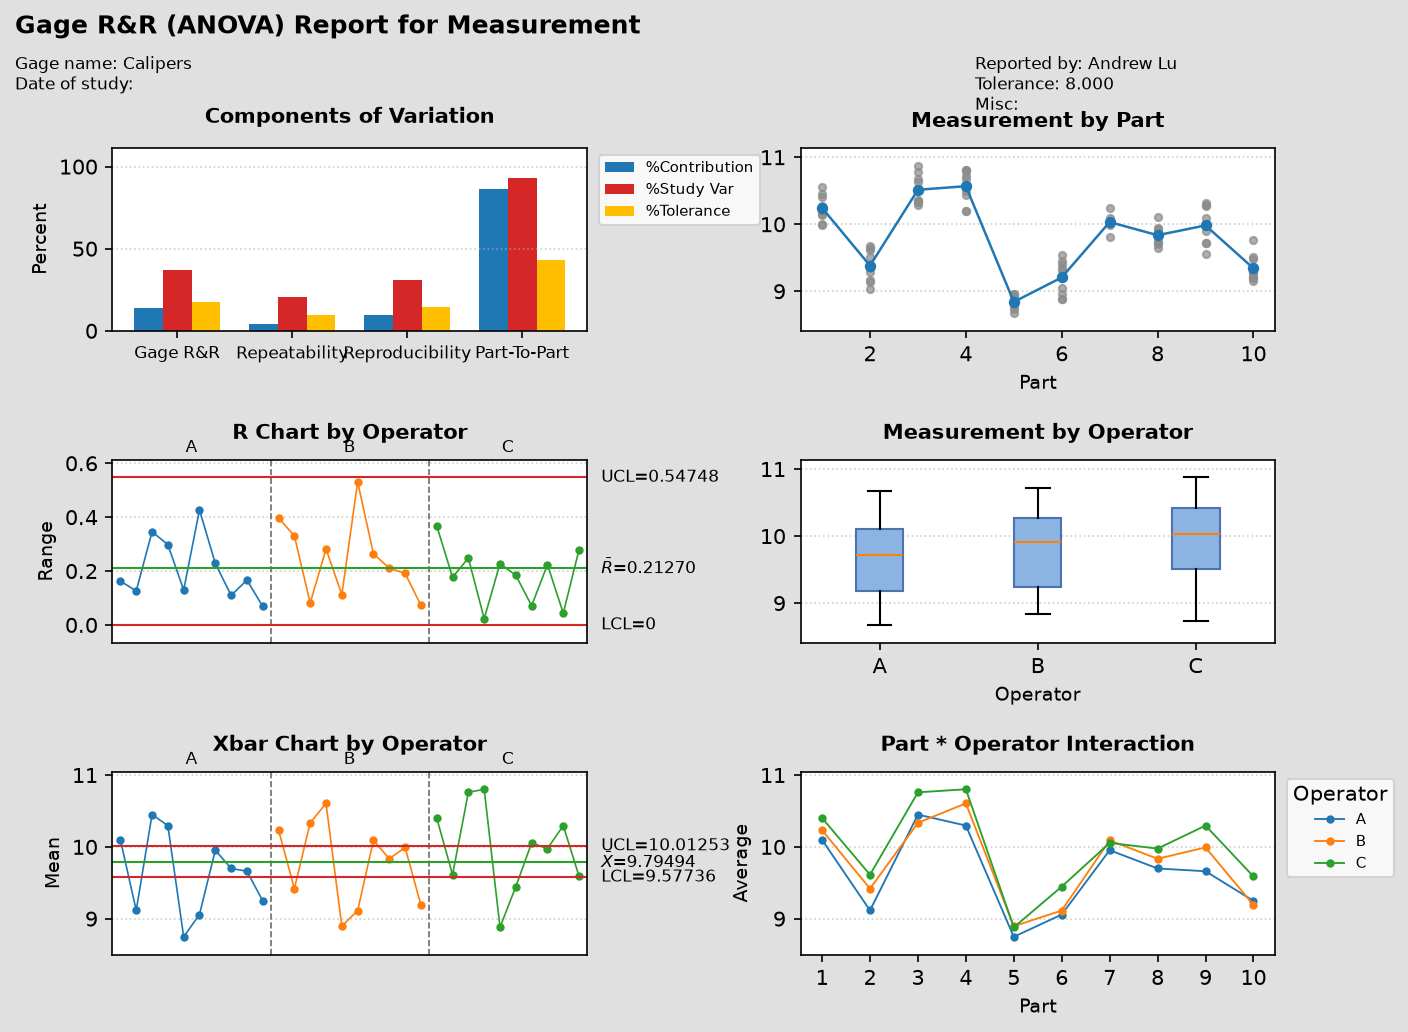

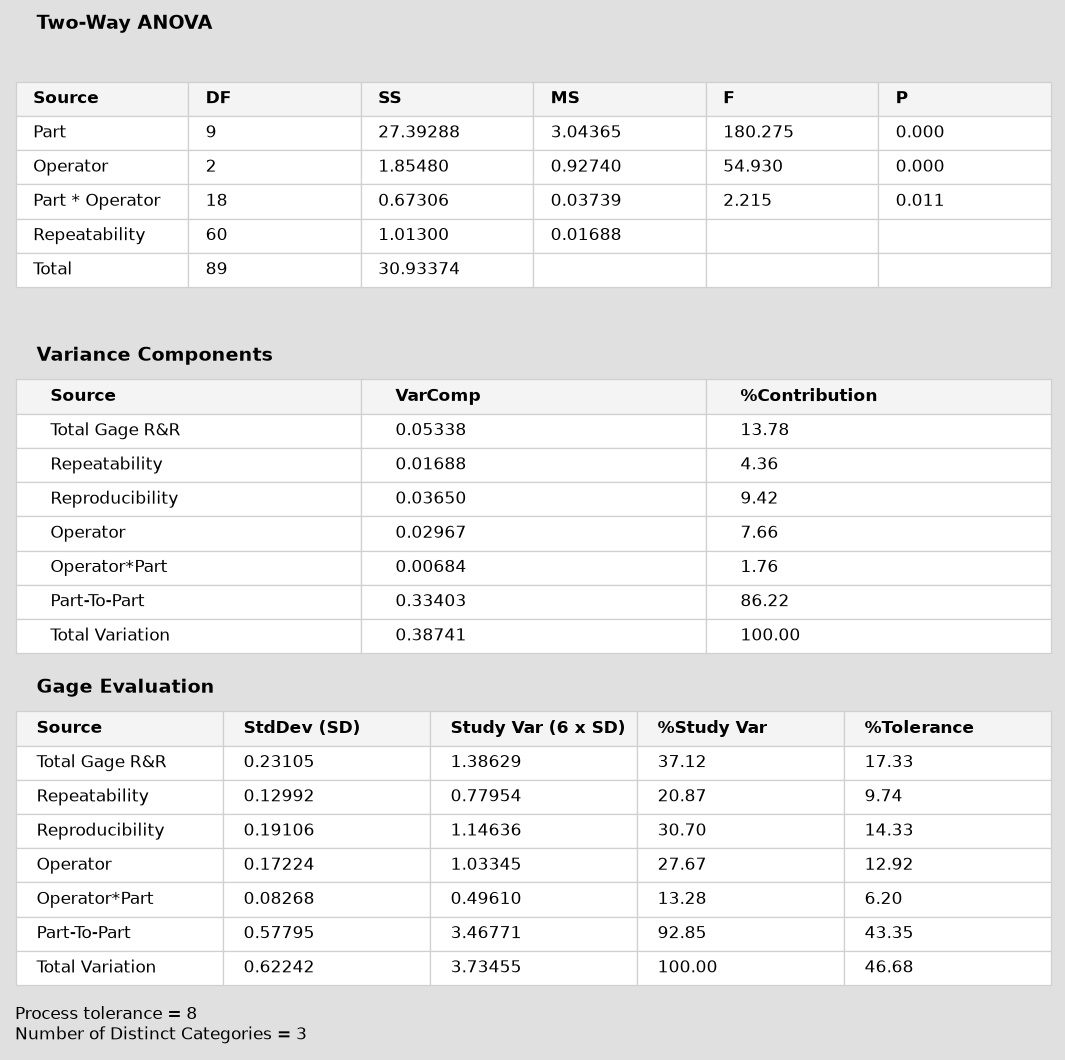

c:\Users\dmnandlu\DeskBox\文件夹\Black belt\capability-sixpack\src\sixpack_report.py:1709: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.93])


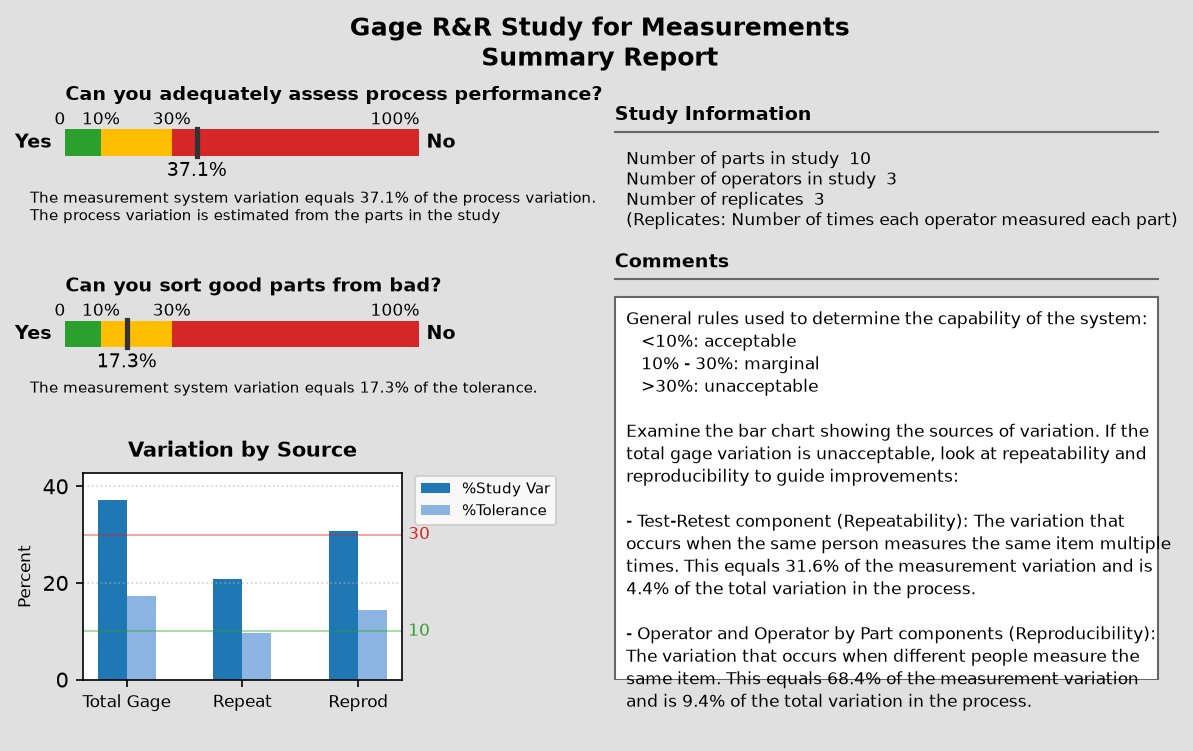

Report saved to    c:\Users\dmnandlu\DeskBox\文件夹\Black belt\capability-sixpack\output\gage_rr_report.png
Assistant saved to c:\Users\dmnandlu\DeskBox\文件夹\Black belt\capability-sixpack\output\gage_rr_assistant.png


In [ ]:
gage_records = sr._synthetic_gage_rr_data(parts_count=10, operators_count=3, seed=42)
gage_specs = sr.GageRrSpecs(
    tolerance=8.0,
    gage_name="Calipers",
    reported_by="Andrew Lu",
)

gage_path = REPO / "output" / "gage_rr_report.png"
assistant_path = REPO / "output" / "gage_rr_assistant.png"

gage_result = sr.generate_gage_rr_report(
    gage_records,
    "Gage R&R (ANOVA) Report for Measurement",
    gage_path,
    specs=gage_specs,
    assistant_output_path=assistant_path,
)
print(f"Report saved to    {gage_path}")
print(f"Assistant saved to {assistant_path}")

In [ ]:
print(sr._format_table(gage_result.anova_with_interaction))
print()
if gage_result.anova_without_interaction is not None:
    print(sr._format_table(gage_result.anova_without_interaction))

Two-Way ANOVA
Source           DF  SS        MS       F        P    
---------------  --  --------  -------  -------  -----
Part             9   27.39288  3.04365  180.275  0.000
Operator         2   1.85480   0.92740  54.930   0.000
Part * Operator  18  0.67306   0.03739  2.215    0.011
Repeatability    60  1.01300   0.01688                
Total            89  30.93374                         



In [ ]:
print(sr._format_table(gage_result.variance_components))
print()
print(sr._format_table(gage_result.gage_evaluation))
print()
print(f"Number of Distinct Categories = {gage_result.distinct_categories}")
print(f"Interaction p-value          = {gage_result.interaction_p_value:.4f}")

Variance Components
Source           VarComp  %Contribution
---------------  -------  -------------
Total Gage R&R   0.05338  13.78        
Repeatability    0.01688  4.36         
Reproducibility  0.03650  9.42         
Operator         0.02967  7.66         
Operator*Part    0.00684  1.76         
Part-To-Part     0.33403  86.22        
Total Variation  0.38741  100.00       

Gage Evaluation
Source           StdDev (SD)  Study Var (6 x SD)  %Study Var  %Tolerance
---------------  -----------  ------------------  ----------  ----------
Total Gage R&R   0.23105      1.38629             37.12       17.33     
Repeatability    0.12992      0.77954             20.87       9.74      
Reproducibility  0.19106      1.14636             30.70       14.33     
Operator         0.17224      1.03345             27.67       12.92     
Operator*Part    0.08268      0.49610             13.28       6.20      
Part-To-Part     0.57795      3.46771             92.85       43.35     
Total Variation  0.

### 5.1 Interpretation

In [ ]:
# The evaluation table carries "%Study Var" for Total Gage R&R; pull it out
# and apply the AIAG thresholds to it.
eval_table = gage_result.gage_evaluation
study_col = eval_table.columns.index("%Study Var")
pct_study = float(
    next(row[study_col] for row in eval_table.rows if row[0] == "Total Gage R&R")
)

# _assessment_for_percent returns (status, verdict).
status, verdict = sr._assessment_for_percent(pct_study)
display(pd.DataFrame({
    "Measure": ["%Study Variation", "Acceptable?", "Assessment"],
    "Value": [f"{pct_study:.1f}%", status, verdict],
}))

,Measure,Value
0,%Study Variation,37.1%
1,Acceptable?,No
2,Assessment,unacceptable


| %Study Var | Verdict |
|---|---|
| < 10% | Acceptable |
| 10 – 30% | Marginal — application dependent |
| > 30% | Unacceptable — improve the measurement system |

The **MSA Assistant** panel above renders the same verdict as a gauge, which
is easier to read in a design review than a table of percentages.

## 6. Bringing your own data

The report functions take plain sequences, so real measurement data drops
straight in. Replace the three values below with your own.

C:\Users\dmnandlu\DeskBox\文件夹\Black belt\capability-sixpack\src\sixpack_report.py:1890: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


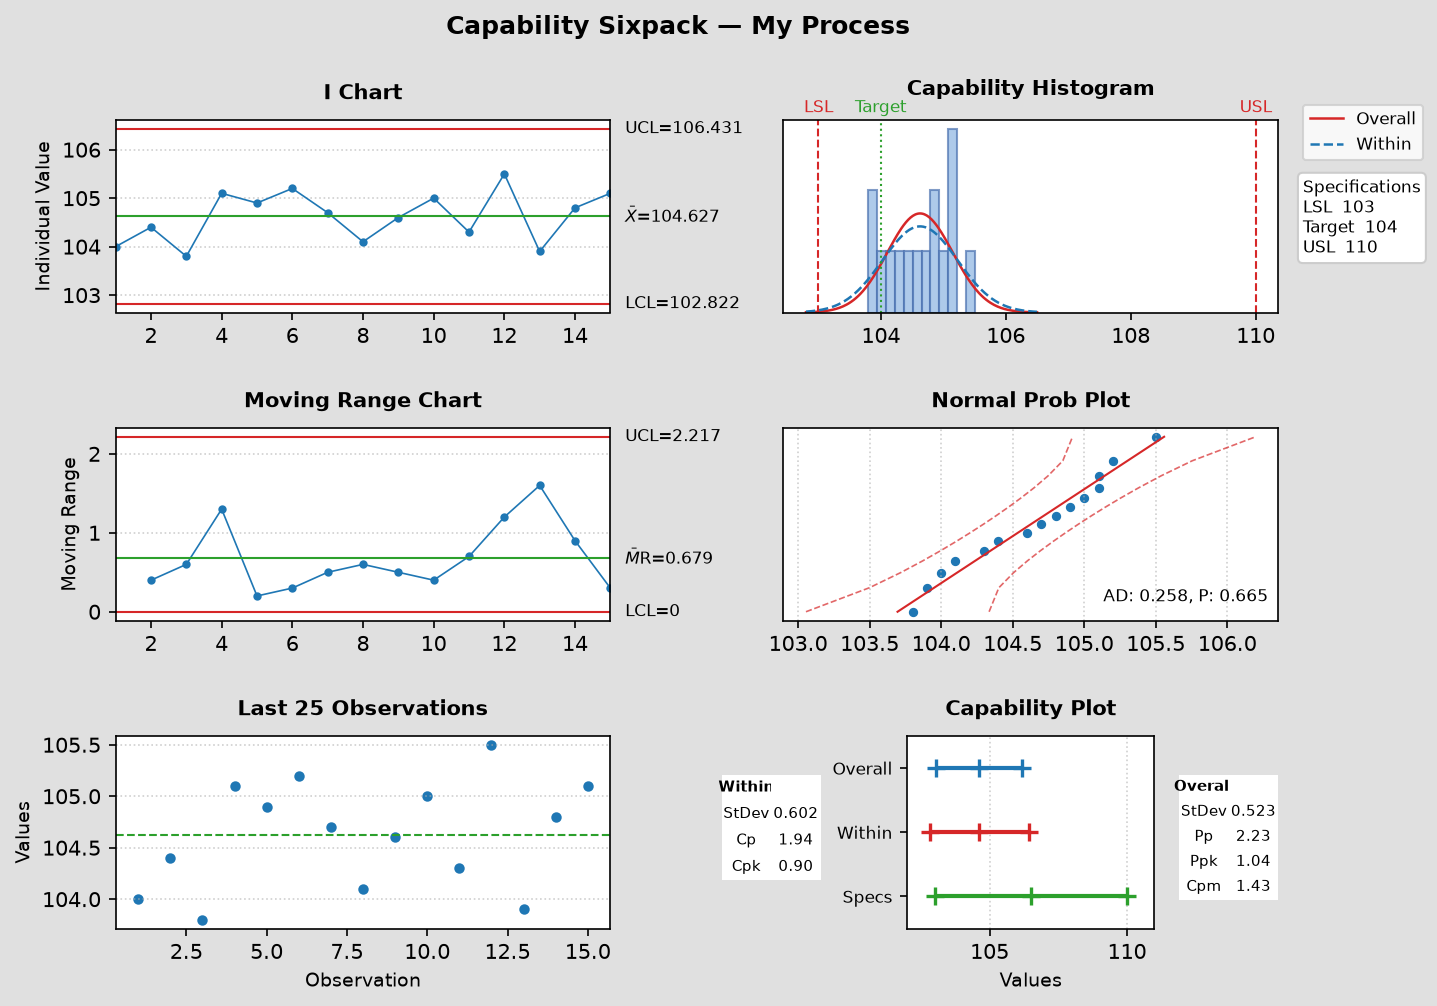

Saved to C:\Users\dmnandlu\DeskBox\文件夹\Black belt\capability-sixpack\output\my_process_sixpack.png
Mean = 104.627   Cpk = 0.901


In [ ]:
my_values = [
    104.0, 104.4, 103.8, 105.1, 104.9,
    105.2, 104.7, 104.1, 104.6, 105.0,
    104.3, 105.5, 103.9, 104.8, 105.1,
]
my_specs = sr.CapabilitySpecs(lsl=103.0, usl=110.0, target=104.0)

my_path = REPO / "output" / "my_process_sixpack.png"

my_stats = sr.generate_sixpack(
    my_values,
    my_specs,
    "Capability Sixpack — My Process",
    my_path,
)
print(f"Saved to {my_path}")
print(f"Mean = {my_stats.mean:.3f}   Cpk = {my_stats.cpk:.3f}")

Gage R&R works the same way — pass a list of `GageRrRecord(part, operator,
measurement)`. A `pandas.DataFrame` with those three columns can be converted
with a comprehension:

```python
records = [
    sr.GageRrRecord(row.part, row.operator, row.measurement)
    for row in df.itertuples()
]
```

## 7. Command line

The same three reports are available without writing any code:

```bash
python src/sixpack_report.py --download-fonts               # sixpack
python src/sixpack_report.py --capability-analysis          # capability analysis
python src/sixpack_report.py --gage-rr                      # gage R&R + assistant
```

Useful flags: `--gage-parts N`, `--gage-operators N` control the synthetic
study size; `--no-fonts` skips the Plus Jakarta Sans download.

Notebook kernel used to build this report: `src/sixpack_report.py` via
`import sixpack_report as sr`.